# 03 Feature 1: Multimodal Fusion Training

Implementation of the proposed system: **ResNet18-biLSTM Fusion Model** using the processed IU X-Ray data.

## 1. Environment & Global Setup

In [1]:
import os
import platform
import torch
from pathlib import Path

def setup_environment():
    print("--- MediSim Environment Setup ---")
    is_colab = "COLAB_GPU" in os.environ
    if is_colab:
        from google.colab import drive
        drive.mount('/content/drive')
        # Set working directory to the notebooks folder in Drive
        project_path = '/content/drive/My Drive/AIT/NLP/NLP_Project/MediSim/notebooks'
        if os.path.exists(project_path):
            os.chdir(project_path)
            print(f"Colab: Connected and switched to {os.getcwd()}")
        else:
            print(f"WARNING: Project path not found: {project_path}")

    device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    return device

device = setup_environment()

--- MediSim Environment Setup ---
Device: mps


In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import collections
import numpy as np
import random
import sys
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Add backend path to import multimodal model definition
sys.path.append('../web_app_pro/backend')
from models import get_model

print("Dependencies Loaded")

Dependencies Loaded


## 2. Dataset & Training
Standard training loop with multimodal feature fusion.

In [3]:
class IU_XRayDataset(Dataset):
    def __init__(self, csv_file, img_dir, vocab=None, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.vocab = vocab
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.df['label_idx'] = self.label_encoder.fit_transform(self.df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_name).convert('RGB')
        if self.transform: image = self.transform(image)
        text = self.df.iloc[idx]['findings']
        tokens = [self.vocab.get(w, 0) for w in str(text).split()][:50]
        tokens = tokens + [0] * (50 - len(tokens))
        return image, torch.tensor(tokens, dtype=torch.long), torch.tensor(self.df.iloc[idx]['label_idx'])

def save_fusion_artifacts(model, vocab, label_encoder):
    save_dir = "../data"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "medisim_diagnostic_model.pth"))
    torch.save(vocab, os.path.join(save_dir, "vocab.pth"))
    torch.save(label_encoder, os.path.join(save_dir, "label_encoder.pth"))
    print(f"Diagnostic model and metadata saved to {save_dir}/")

print("Dataset Class & Saving Logic Ready")

Dataset Class & Saving Logic Ready


## 3. Multimodal Training & Evaluation
We implement a full 5-epoch training loop to achieve competitive diagnostic performance.

In [4]:
# Configuration
METADATA_PATH = "../data/processed_metadata.csv"
IMAGES_DIR = "../data/images/images_normalized"
MODEL_PATH = "../data/medisim_diagnostic_model.pth"

EPOCHS = 5
BATCH_SIZE = 16
TRAIN_FROM_SCRATCH = True
SEED = 42

def compute_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, texts, labels in loader:
            outputs = model(images.to(device), texts.to(device))
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    return {
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'evaluated_samples': int(len(all_labels))
    }, all_labels, all_preds

if os.path.exists(METADATA_PATH):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Define vocabulary from findings text.
    df = pd.read_csv(METADATA_PATH)
    all_text = " ".join(df['findings'].astype(str))
    words = all_text.split()
    word_counts = collections.Counter(words)
    vocab = {w: i + 1 for i, (w, _) in enumerate(word_counts.most_common(5000))}
    vocab['<pad>'] = 0

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    dataset = IU_XRayDataset(METADATA_PATH, IMAGES_DIR, vocab=vocab, transform=transform)

    n_total = len(dataset)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    split_generator = torch.Generator().manual_seed(SEED)
    train_set, val_set, test_set = random_split(
        dataset, [n_train, n_val, n_test], generator=split_generator
    )

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

    num_classes = len(dataset.label_encoder.classes_)
    model = get_model(vocab_size=len(vocab), num_classes=num_classes, device=device).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    print("--- Starting Multimodal Training ---")
    print(
        f"Samples: {len(dataset)} (train={len(train_set)}, val={len(val_set)}, test={len(test_set)}) "
        f"| Epochs: {EPOCHS}"
    )

    training_history = {
        'epoch_loss': [],
        'epoch_accuracy': [],
        'val_f1': []
    }

    if os.path.exists(MODEL_PATH) and not TRAIN_FROM_SCRATCH:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print(f"Loaded checkpoint without retraining: {MODEL_PATH}")
    else:
        best_val_f1 = -1.0
        best_state = None

        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            running_correct = 0
            running_total = 0

            for images, texts, labels in train_loader:
                images, texts, labels = images.to(device), texts.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images, texts)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                running_correct += (preds == labels).sum().item()
                running_total += labels.size(0)

            epoch_loss = running_loss / max(len(train_loader), 1)
            epoch_acc = running_correct / max(running_total, 1)

            val_metrics, _, _ = compute_metrics(model, val_loader, device)

            training_history['epoch_loss'].append(float(epoch_loss))
            training_history['epoch_accuracy'].append(float(epoch_acc))
            training_history['val_f1'].append(float(val_metrics['f1']))

            print(
                f"Epoch [{epoch + 1}/{EPOCHS}] "
                f"Loss: {epoch_loss:.4f} "
                f"Train Acc: {epoch_acc:.4f} "
                f"Val F1: {val_metrics['f1']:.4f}"
            )

            if val_metrics['f1'] > best_val_f1:
                best_val_f1 = val_metrics['f1']
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if best_state is not None:
            model.load_state_dict(best_state)
            print(f"Best validation F1 selected: {best_val_f1:.4f}")

        # Save best model and metadata artifacts.
        save_fusion_artifacts(model, vocab, dataset.label_encoder)

    # Final evaluation on unseen test split.
    fusion_metrics, all_labels, all_preds = compute_metrics(model, test_loader, device)
    print("\n--- Final Test Metrics ---")
    print(
        f"Accuracy: {fusion_metrics['accuracy']:.4f} | "
        f"Precision: {fusion_metrics['precision']:.4f} | "
        f"Recall: {fusion_metrics['recall']:.4f} | "
        f"F1: {fusion_metrics['f1']:.4f}"
    )
    print("--------------------------------")

    # Keep these names for downstream visualization cell compatibility.
    loader = test_loader
else:
    print("Metadata not found! Run 01_data_pipeline.ipynb first.")

--- Starting Multimodal Training ---
Samples: 2771 (train=1939, val=415, test=417) | Epochs: 5
Epoch [1/5] Loss: 1.9488 Train Acc: 0.4482 Val F1: 0.3454
Epoch [2/5] Loss: 1.5449 Train Acc: 0.5353 Val F1: 0.4087
Epoch [3/5] Loss: 1.2528 Train Acc: 0.6111 Val F1: 0.4504
Epoch [4/5] Loss: 0.8875 Train Acc: 0.7329 Val F1: 0.4819
Epoch [5/5] Loss: 0.5225 Train Acc: 0.8453 Val F1: 0.4693
Best validation F1 selected: 0.4819
Diagnostic model and metadata saved to ../data/

--- Final Test Metrics ---
Accuracy: 0.4940 | Precision: 0.4342 | Recall: 0.4940 | F1: 0.4499
--------------------------------


## 4. Visualization: Fusion Training Insights
This section visualizes epoch loss/accuracy and confusion matrix, then exports chart-ready metrics for the web dashboard.

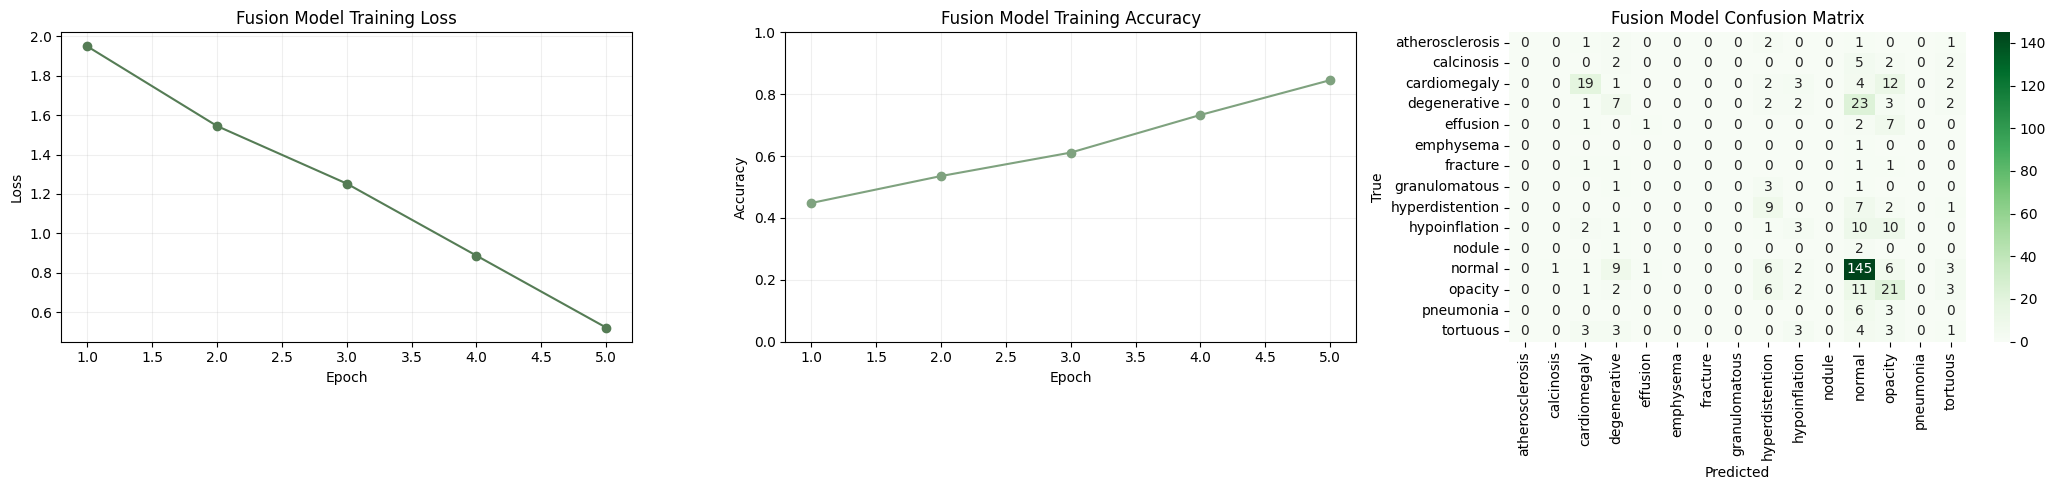

Fusion-only insights exported to: ../data/fusion_insights.json
Fusion-only web data updated at: ../web_app_pro/frontend/public/fusion_insights.json


In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if all(name in globals() for name in ['training_history', 'all_labels', 'all_preds', 'dataset', 'fusion_metrics']):
    class_names = dataset.label_encoder.classes_.tolist()
    cm = confusion_matrix(all_labels, all_preds)
    support = [int((np.array(all_labels) == i).sum()) for i in range(len(class_names))]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    epochs = list(range(1, len(training_history['epoch_loss']) + 1))
    axes[0].plot(epochs, training_history['epoch_loss'], marker='o', color='#557c55')
    axes[0].set_title('Fusion Model Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.2)

    axes[1].plot(epochs, training_history['epoch_accuracy'], marker='o', color='#7fa27f')
    axes[1].set_title('Fusion Model Training Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.2)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[2]
    )
    axes[2].set_title('Fusion Model Confusion Matrix')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('True')

    plt.tight_layout()
    plt.show()

    fusion_insights = {
        'summary': fusion_metrics,
        'epoch_loss': [float(x) for x in training_history['epoch_loss']],
        'epoch_accuracy': [float(x) for x in training_history['epoch_accuracy']],
        'class_names': class_names,
        'confusion_matrix': cm.tolist(),
        'class_support': support
    }

    # Fusion-only export (prevents overwrite of baseline-only file).
    fusion_path = Path('../data/fusion_insights.json')
    fusion_path.parent.mkdir(parents=True, exist_ok=True)
    with open(fusion_path, 'w') as f:
        json.dump({'multimodal_fusion': fusion_insights}, f, indent=2)

    fusion_web_path = Path('../web_app_pro/frontend/public/fusion_insights.json')
    fusion_web_path.parent.mkdir(parents=True, exist_ok=True)
    with open(fusion_web_path, 'w') as f:
        json.dump({'multimodal_fusion': fusion_insights}, f, indent=2)

    # Optional merged export for backward compatibility.
    merged_path = Path('../data/model_insights.json')
    merged = {}
    if merged_path.exists():
        with open(merged_path, 'r') as f:
            merged = json.load(f)
    merged['multimodal_fusion'] = fusion_insights
    with open(merged_path, 'w') as f:
        json.dump(merged, f, indent=2)

    merged_web_path = Path('../web_app_pro/frontend/public/model_insights.json')
    with open(merged_web_path, 'w') as f:
        json.dump(merged, f, indent=2)

    print(f'Fusion-only insights exported to: {fusion_path}')
    print(f'Fusion-only web data updated at: {fusion_web_path}')
else:
    print('Please run the full training cell first so history and predictions are available.')

## Retraining Upgrade (Notebook Workflow)

This section ports the retraining pipeline from `scripts/retrain_diagnostic_model.py` into notebook cells.

What this retraining improves:
- Cleans placeholder tokens like `XXXX` from text.
- Uses weighted sampling + weighted loss for class imbalance.
- Saves retrained artifacts to `data/`.
- Exports retraining insights JSON for analysis.

Run cells in order.

In [4]:
import os
import re
import json
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms


def resolve_root_dir() -> Path:
    cwd = Path.cwd().resolve()
    # Typical notebook run location: <repo>/notebooks
    if (cwd / "data").exists() and (cwd / "web_app_pro").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "data").exists():
        return cwd.parent
    # Fallback: walk up parents
    for parent in cwd.parents:
        if (parent / "data").exists() and (parent / "web_app_pro").exists():
            return parent
    raise RuntimeError("Could not resolve MediSim repo root from current working directory.")


ROOT_DIR = resolve_root_dir()
BACKEND_DIR = ROOT_DIR / "web_app_pro" / "backend"

import sys
if str(BACKEND_DIR) not in sys.path:
    sys.path.append(str(BACKEND_DIR))

from models import get_model


@dataclass
class TrainConfig:
    data_csv: str
    image_dir: str
    output_dir: str
    epochs: int = 14
    batch_size: int = 16
    lr: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    max_len: int = 60
    min_freq: int = 2
    seed: int = 42
    patience: int = 4
    min_lr: float = 1e-6
    use_weighted_sampler: bool = True


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clean_text(text: str) -> str:
    text = str(text or "").lower()
    text = re.sub(r"\b(xxxx|xx|x)\b", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_text_field(df: pd.DataFrame) -> pd.Series:
    cols = [c for c in ["indication", "findings", "impression"] if c in df.columns]
    if not cols:
        return pd.Series([""] * len(df))
    merged = df[cols].fillna("").agg(" ".join, axis=1)
    return merged.map(clean_text)


def build_vocab(texts, min_freq: int = 2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = len(vocab)
    return vocab


def encode_text(text: str, vocab: dict, max_len: int):
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in text.split()][:max_len]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids


class FusionDataset(Dataset):
    def __init__(self, df, image_dir, vocab, label_encoder, transform, max_len):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.vocab = vocab
        self.label_encoder = label_encoder
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["filename"])

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        text_ids = encode_text(row["text_input"], self.vocab, self.max_len)
        text_tensor = torch.tensor(text_ids, dtype=torch.long)

        label_id = int(self.label_encoder.transform([row["label"]])[0])
        label_tensor = torch.tensor(label_id, dtype=torch.long)

        return img, text_tensor, label_tensor


def make_dataloaders(df, cfg: TrainConfig, vocab, label_encoder):
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=cfg.seed,
        stratify=df["label"],
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=cfg.seed,
        stratify=temp_df["label"],
    )

    train_tfm = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.2),
            transforms.RandomAffine(degrees=7, translate=(0.03, 0.03), scale=(0.97, 1.03)),
            transforms.ColorJitter(brightness=0.08, contrast=0.08),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    eval_tfm = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    train_ds = FusionDataset(train_df, cfg.image_dir, vocab, label_encoder, train_tfm, cfg.max_len)
    val_ds = FusionDataset(val_df, cfg.image_dir, vocab, label_encoder, eval_tfm, cfg.max_len)
    test_ds = FusionDataset(test_df, cfg.image_dir, vocab, label_encoder, eval_tfm, cfg.max_len)

    if cfg.use_weighted_sampler:
        class_counts = train_df["label"].value_counts()
        weights = train_df["label"].map(lambda x: 1.0 / class_counts[x]).values
        sampler = WeightedRandomSampler(
            weights=torch.tensor(weights, dtype=torch.double),
            num_samples=len(weights),
            replacement=True,
        )
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler)
    else:
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)

    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, train_df


def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, txt, y in loader:
            imgs = imgs.to(device)
            txt = txt.to(device)
            y = y.to(device)
            logits = model(imgs, txt)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "samples": len(y_true),
    }

In [5]:
def train_retrained_fusion(cfg: TrainConfig):
    set_seed(cfg.seed)

    df = pd.read_csv(cfg.data_csv)
    required_cols = {"filename", "label"}
    if not required_cols.issubset(set(df.columns)):
        raise ValueError(f"{cfg.data_csv} must contain columns: {sorted(required_cols)}")

    df = df.copy()
    df["text_input"] = build_text_field(df)
    df = df[df["filename"].notna() & df["label"].notna()].copy()

    df["img_exists"] = df["filename"].map(lambda f: os.path.exists(os.path.join(cfg.image_dir, f)))
    missing = int((~df["img_exists"]).sum())
    if missing > 0:
        print(f"Dropping {missing} rows with missing image files.")
        df = df[df["img_exists"]].copy()

    vocab = build_vocab(df["text_input"].tolist(), min_freq=cfg.min_freq)
    label_encoder = LabelEncoder()
    label_encoder.fit(df["label"].astype(str))

    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    print("Using device:", device)

    model = get_model(vocab_size=len(vocab), num_classes=len(label_encoder.classes_), device=device)
    train_loader, val_loader, test_loader, train_df = make_dataloaders(df, cfg, vocab, label_encoder)

    train_counts = train_df["label"].value_counts()
    class_weight_values = [1.0 / float(train_counts.get(cls, 1.0)) for cls in label_encoder.classes_]
    class_weights = torch.tensor(class_weight_values, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg.label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2, min_lr=cfg.min_lr
    )

    best_val_macro_f1 = -1.0
    best_state = None
    best_epoch = -1
    wait = 0
    epoch_loss, epoch_acc = [], []

    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, txt, y in train_loader:
            imgs = imgs.to(device)
            txt = txt.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(imgs, txt)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * y.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += int((preds == y).sum().item())
            total += int(y.size(0))

        train_loss = running_loss / max(total, 1)
        train_acc = correct / max(total, 1)
        val_metrics = evaluate(model, val_loader, device)
        val_macro_f1 = val_metrics["f1_macro"]
        scheduler.step(val_macro_f1)

        epoch_loss.append(train_loss)
        epoch_acc.append(train_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1}/{cfg.epochs} | "
            f"lr={current_lr:.2e} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_f1_macro={val_metrics['f1_macro']:.4f} val_f1_weighted={val_metrics['f1_weighted']:.4f}"
        )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch + 1
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg.patience:
                print(f"Early stopping at epoch {epoch + 1} (best epoch={best_epoch}).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_loader, device)
    os.makedirs(cfg.output_dir, exist_ok=True)

    model_path = os.path.join(cfg.output_dir, "medisim_diagnostic_model_retrained.pth")
    vocab_path = os.path.join(cfg.output_dir, "vocab_retrained.pth")
    encoder_path = os.path.join(cfg.output_dir, "label_encoder_retrained.pth")
    insights_path = os.path.join(cfg.output_dir, "retrained_fusion_insights.json")

    torch.save(model.state_dict(), model_path)
    torch.save(vocab, vocab_path)
    torch.save(label_encoder, encoder_path)

    insights = {
        "retrained_multimodal_fusion": {
            "summary": test_metrics,
            "selection_metric": "val_f1_macro",
            "best_epoch": best_epoch,
            "best_val_f1_macro": float(best_val_macro_f1),
            "epoch_loss": epoch_loss,
            "epoch_accuracy": epoch_acc,
            "class_names": list(label_encoder.classes_),
            "config": {
                "epochs": cfg.epochs,
                "batch_size": cfg.batch_size,
                "lr": cfg.lr,
                "weight_decay": cfg.weight_decay,
                "label_smoothing": cfg.label_smoothing,
                "patience": cfg.patience,
                "min_lr": cfg.min_lr,
                "max_len": cfg.max_len,
                "min_freq": cfg.min_freq,
                "seed": cfg.seed,
                "weighted_sampler": cfg.use_weighted_sampler,
            },
        }
    }

    with open(insights_path, "w", encoding="utf-8") as f:
        json.dump(insights, f, indent=2)

    print("\nRetraining complete.")
    print("Model:", model_path)
    print("Vocab:", vocab_path)
    print("Label encoder:", encoder_path)
    print("Insights:", insights_path)
    print("Test metrics:", test_metrics)

    return {
        "model_path": model_path,
        "vocab_path": vocab_path,
        "encoder_path": encoder_path,
        "insights_path": insights_path,
        "test_metrics": test_metrics,
    }


cfg = TrainConfig(
    data_csv=str(ROOT_DIR / "data" / "processed_metadata.csv"),
    image_dir=str(ROOT_DIR / "data" / "images" / "images_normalized"),
    output_dir=str(ROOT_DIR / "data"),
    epochs=14,
    batch_size=16,
    lr=3e-4,
    weight_decay=1e-4,
    label_smoothing=0.05,
    max_len=60,
    min_freq=2,
    seed=42,
    patience=4,
    min_lr=1e-6,
    use_weighted_sampler=True,
)

print(cfg)

# Uncomment next line to start retraining.
# retrain_outputs = train_retrained_fusion(cfg)

TrainConfig(data_csv='/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/NLP/NLP_Project/MediSim/data/processed_metadata.csv', image_dir='/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/NLP/NLP_Project/MediSim/data/images/images_normalized', output_dir='/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/NLP/NLP_Project/MediSim/data', epochs=14, batch_size=16, lr=0.0003, weight_decay=0.0001, label_smoothing=0.05, max_len=60, min_freq=2, seed=42, patience=4, min_lr=1e-06, use_weighted_sampler=True)


### How to run improved retraining

1. Run the import/helper cell (Cell 12).
2. Review `cfg` values in the training cell (Cell 13).
3. Run retraining cell (Cell 15).
4. Run comparison cell (Cell 16) to decide baseline vs retrained automatically.

Saved outputs in `data/`:
- `medisim_diagnostic_model_retrained.pth`
- `vocab_retrained.pth`
- `label_encoder_retrained.pth`
- `retrained_fusion_insights.json`

Tip: selection metric is now `val_f1_macro` (better for class imbalance than weighted F1).

In [6]:
retrain_outputs = train_retrained_fusion(cfg)

Using device: mps
Epoch 1/14 | lr=3.00e-04 train_loss=1.9890 train_acc=0.1851 val_f1_macro=0.0224 val_f1_weighted=0.0086
Epoch 2/14 | lr=3.00e-04 train_loss=1.3403 train_acc=0.3347 val_f1_macro=0.0276 val_f1_weighted=0.0120
Epoch 3/14 | lr=3.00e-04 train_loss=1.0145 train_acc=0.4678 val_f1_macro=0.0618 val_f1_weighted=0.0345
Epoch 4/14 | lr=3.00e-04 train_loss=0.8517 train_acc=0.5369 val_f1_macro=0.0867 val_f1_weighted=0.0566
Epoch 5/14 | lr=3.00e-04 train_loss=0.7342 train_acc=0.6070 val_f1_macro=0.0567 val_f1_weighted=0.0300
Epoch 6/14 | lr=3.00e-04 train_loss=0.6559 train_acc=0.6411 val_f1_macro=0.1438 val_f1_weighted=0.1021
Epoch 7/14 | lr=3.00e-04 train_loss=0.5434 train_acc=0.6942 val_f1_macro=0.1055 val_f1_weighted=0.0564
Epoch 8/14 | lr=3.00e-04 train_loss=0.5882 train_acc=0.6906 val_f1_macro=0.1366 val_f1_weighted=0.0941
Epoch 9/14 | lr=3.00e-04 train_loss=0.4967 train_acc=0.7375 val_f1_macro=0.1765 val_f1_weighted=0.1399
Epoch 10/14 | lr=3.00e-04 train_loss=0.4733 train_acc=0

In [7]:
from pathlib import Path
import json

data_dir = ROOT_DIR / "data"
baseline_path = data_dir / "model_insights.json"
retrained_path = data_dir / "retrained_fusion_insights.json"

def _read_summary(path: Path):
    if not path.exists():
        return {}
    payload = json.loads(path.read_text(encoding="utf-8"))
    if "summary" in payload and isinstance(payload["summary"], dict):
        return payload["summary"]
    for value in payload.values():
        if isinstance(value, dict) and isinstance(value.get("summary"), dict):
            return value["summary"]
    return {}

base = _read_summary(baseline_path)
new = _read_summary(retrained_path)

print("Baseline:", base)
print("Retrained:", new)

base_f1 = float(base.get("f1", base.get("f1_weighted", 0.0)) or 0.0)
new_f1 = float(new.get("f1", new.get("f1_weighted", 0.0)) or 0.0)
base_acc = float(base.get("accuracy", 0.0) or 0.0)
new_acc = float(new.get("accuracy", 0.0) or 0.0)

if (new_f1, new_acc) > (base_f1, base_acc):
    print("Recommendation: use retrained artifacts.")
else:
    print("Recommendation: keep baseline artifacts.")

Baseline: {'accuracy': 0.460431654676259, 'precision': 0.4309808270772866, 'recall': 0.460431654676259, 'f1': 0.4352336456322647, 'samples': 417}
Retrained: {'accuracy': 0.24759615384615385, 'precision_weighted': 0.5003335567688784, 'recall_weighted': 0.24759615384615385, 'f1_weighted': 0.22592356493467744, 'precision_macro': 0.2822179133224137, 'recall_macro': 0.3426856952881074, 'f1_macro': 0.2601883076002713, 'samples': 416}
Recommendation: keep baseline artifacts.
